<a href="https://colab.research.google.com/github/MartinsOluwatobi/CV-Learning-Journal-/blob/main/Weight_and_Bias_Assignment_MLC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torchvision import datasets, transforms
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import models
from tqdm import tqdm

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: martinsmichael (martinsmichael-nil) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Data Collection from Kaggle


In [3]:
import kagglehub
path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")


Using Colab cache for faster access to the 'handwritten-digits-0-9' dataset.


In [4]:
'''Check if the folder-file and filenaming system suits ImageFolder
  ImageFolder expects filename in /root/class/img format'''
for root,dir,files in os.walk(path):
  for file in files:
      if file.lower().endswith(('.jpeg','.png','.jpg')):
         print(str(root))
         print(file)
         break

/kaggle/input/handwritten-digits-0-9/7
Seven_full (1822).jpg
/kaggle/input/handwritten-digits-0-9/2
Two_full (1663).jpg
/kaggle/input/handwritten-digits-0-9/5
Five_full (960).jpg
/kaggle/input/handwritten-digits-0-9/8
Eight_full (977).jpg
/kaggle/input/handwritten-digits-0-9/0
Zero_full (675).jpg
/kaggle/input/handwritten-digits-0-9/3
Three_full (77).jpg
/kaggle/input/handwritten-digits-0-9/1
One_full (1990).jpg
/kaggle/input/handwritten-digits-0-9/4
Four_full (941).jpg
/kaggle/input/handwritten-digits-0-9/9
Nine_full (1441).jpg
/kaggle/input/handwritten-digits-0-9/6
Six_full (284).jpg


In [5]:
# Resize images to 3x64x64 (CxHxW) >> convert to tensor >> Augment the dataset by rotating 30% of the total dataset by 30 degrees
transform = transforms.Compose([transforms.Resize((64,64)),
                                transforms.ToTensor(),
                                transforms.RandomApply([transforms.RandomRotation(30)], p=0.3)])
data  = datasets.ImageFolder(path, transform = transform)
num_class = len(data.classes)



In [6]:
data.classes

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

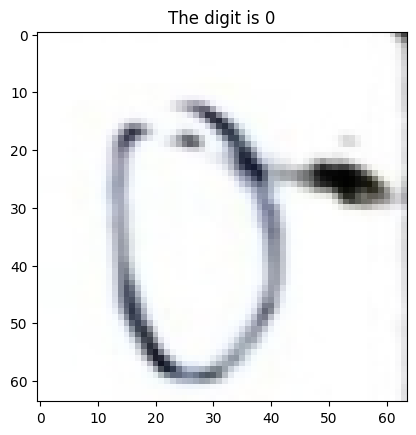

In [7]:
#Visualize image sample
sample_image, label = next(iter(data))
sample_image = sample_image.permute(1,2,0)
plt.imshow(sample_image)
plt.title(f'The digit is {label}')
plt.show()

In [8]:
# Build Class for Custom Dataset
class DigitDataset(Dataset):
  def __init__ (self,data):
    self.data = data

  def __len__ (self):
    return len(self.data)

  def __getitem__(self, idx):
      img, label = self.data[idx]
      return img, label

In [9]:
#Split data into train and test data
train_data, test_data = train_test_split(data, test_size= 0.2, random_state = 42, shuffle = True)
train_data = DigitDataset(train_data)
test_data = DigitDataset(test_data)

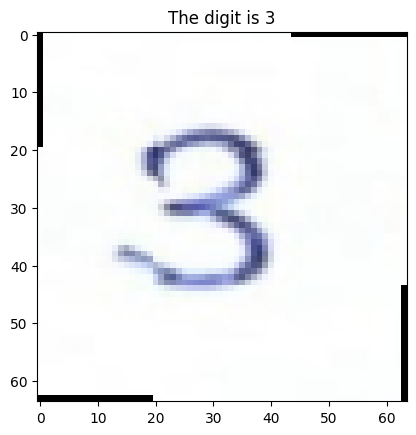

In [10]:
# Vizualise a sample data after data augmentation
image_1,label_1 = test_data[0]
image_1 = image_1.permute(1,2,0)
plt.imshow(image_1)
plt.title(f'The digit is {label_1}')
plt.show()

In [11]:
class DigitClassifier(nn.Module):
  def __init__(self, num_class):
    super().__init__()
    self.conv = nn.Sequential(
                              nn.Conv2d(in_channels =3,
                                        out_channels = 32,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(32),
                              nn.ReLU(),
                              nn.MaxPool2d(kernel_size = (2,2)),
                              nn.Conv2d(in_channels =32,
                                        out_channels = 64,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(64),
                              nn.ReLU(),
                              nn.MaxPool2d(kernel_size = (2,2)),
                              nn.Conv2d(in_channels =64,
                                        out_channels = 128,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(128),
                              nn.ReLU(),
                              nn.MaxPool2d(kernel_size = (2,2)),
                              nn.Conv2d(in_channels =128,
                                        out_channels = 128,
                                        kernel_size= (3,3),
                                        stride = 1,
                                        padding=1),
                              nn.BatchNorm2d(128),
                              nn.ReLU()
    )
    self.linear = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 8 * 8,1024),
        nn.ReLU(),
        nn.Linear(1024,512),
        nn.ReLU(),
        nn.Linear(512,num_class)
    )

  def forward(self,x):
    x = self.conv(x)
    x= self.linear(x)
    return x



In [12]:
def Accuracy (pred, label):
  pred = torch.argmax(pred, dim =1)
  score = (pred == label).sum().item()
  score /= len(label)
  return score

def train (model, train_dataloader, test_dataloader, optimizer, loss_fn,device):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    for image, label in train_dataloader:
        image = image.to(device)
        label = label.to(device)
        pred = model(image)
        loss = loss_fn(pred,label)
        accuracy = Accuracy(pred,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_accuracy += accuracy
    epoch_loss /= len(train_dataloader)
    epoch_accuracy /= len(train_dataloader)

    model.eval()
    with torch.no_grad():
          epoch_test_loss = 0
          epoch_test_accuracy = 0
          for test_image, test_label in test_dataloader:
              test_image = test_image.to(device)
              test_label = test_label.to(device)
              pred_test = model(test_image)
              test_loss = loss_fn(pred_test, test_label)
              test_accuracy = Accuracy(pred_test, test_label)
              epoch_test_loss += test_loss.item()
              epoch_test_accuracy += test_accuracy
          epoch_test_loss /= len(test_dataloader)
          epoch_test_accuracy /= len(test_dataloader)
    metrics = {'train_loss' : epoch_loss,
               'train_accuracy': epoch_accuracy,
               'test_loss' : epoch_test_loss,
               'test_accuracy': epoch_test_accuracy}
    wandb.log(metrics)
    return epoch_loss, epoch_test_loss, epoch_accuracy, epoch_test_accuracy


    print(f'Epoch {epoch} info')
    print('-'*50)
    print(f'Train loss : {epoch_loss} | Test loss : {epoch_test_loss}')
    print(f'Train accuracy : {epoch_accuracy} | Test accuracy : {epoch_test_accuracy}')



In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
wandb.init( project = 'Digit-Classifier',
           config ={
    'batch_size' : 32,
    'epochs' : 10,
    'learning_rate' : 0.001,
})

train_dataloader = DataLoader(train_data,
                              batch_size = wandb.config.batch_size,
                              shuffle = True
                              )
test_dataloader = DataLoader(test_data,
                             batch_size = wandb.config.batch_size)

model = DigitClassifier(num_class= 10).to(device)
optimizer = torch.optim.SGD(model.parameters(),
                            lr = wandb.config.learning_rate)
loss_fn = nn.CrossEntropyLoss()


for epoch in tqdm(range(wandb.config.epochs)):
    epoch_loss, epoch_test_loss, epoch_accuracy, epoch_test_accuracy = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device)
    print('-'*50)
    print(f'Epoch {epoch} info')
    print('-'*50)
    print(f'Train loss : {epoch_loss} | Test loss : {epoch_test_loss}')
    print(f'Train accuracy : {epoch_accuracy} | Test accuracy : {epoch_test_accuracy}')
wandb.finish()


 10%|█         | 1/10 [00:04<00:36,  4.10s/it]

--------------------------------------------------
Epoch 0 info
--------------------------------------------------
Train loss : 2.251886117878562 | Test loss : 2.183797016850224
Train accuracy : 0.30560893188444205 | Test accuracy : 0.4311795491143317


 20%|██        | 2/10 [00:06<00:26,  3.34s/it]

--------------------------------------------------
Epoch 1 info
--------------------------------------------------
Train loss : 2.0457791222712105 | Test loss : 1.8489491436216565
Train accuracy : 0.49211502782931354 | Test accuracy : 0.5411332528180354


 30%|███       | 3/10 [00:09<00:21,  3.09s/it]

...

 90%|█████████ | 9/10 [00:26<00:02,  2.81s/it]

--------------------------------------------------
Epoch 8 info
--------------------------------------------------
Train loss : 0.38207420242297185 | Test loss : 0.3607309565499977
Train accuracy : 0.8931801616750596 | Test accuracy : 0.903341384863124


100%|██████████| 10/10 [00:29<00:00,  2.92s/it]

--------------------------------------------------
Epoch 9 info
--------------------------------------------------
Train loss : 0.32908684461755966 | Test loss : 0.3105926196884226
Train accuracy : 0.9092648423005566 | Test accuracy : 0.9154287439613527


test_accuracy,▁▃▄▆▆▇▇███
test_loss,█▇▅▃▃▂▂▁▁▁
train_accuracy,▁▃▄▆▆▇▇███
train_loss,█▇▆▄▃▂▂▁▁▁
test_accuracy,0.91543
test_loss,0.31059
train_accuracy,0.90926
train_loss,0.32909


In [ ]:
batch_size = [8,16,32]
learning_rate = [0.01,0.001,0.0001]
epochs_list = [10,15,20]
for batch in batch_size:
    for lr in learning_rate:
        for epoch in epochs_list:
            wandb.init(
                project = 'Digit-Classifier',
                name = f'batch_{batch}_lr_{lr}_epoch_{epoch}',
                 config= {
                'batch_size' : batch,
                'epochs' : epoch,
                'learning_rate' : lr,
            })
            train_dataloader = DataLoader(train_data,
                                          batch_size = wandb.config.batch_size,
                                          shuffle= True)
            test_dataloader = DataLoader(test_data,
                                         batch_size = wandb.config.batch_size)
            model = DigitClassifier(num_class).to(device)
            optimizer = torch.optim.SGD(model.parameters(),
                                        lr = wandb.config.learning_rate)
            loss_fn = nn.CrossEntropyLoss()
            for epoch in tqdm(range(wandb.config.epochs)):
                epoch_loss, epoch_test_loss, epoch_accuracy, epoch_test_accuracy = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device)
                if epoch % 5 == 0:
                   print('-'*50)
                   print(f'Model training info at hyperparam: Batch_size {wandb.config.batch_size}, learning rate : {wandb.config.learning_rate}, and epochs : {wandb.config.epochs}')
                   print('-'*50)
                   print(f'Epoch {epoch} info')
                   print('-'*50)
                   print(f'Train loss : {epoch_loss} | Test loss : {epoch_test_loss}')
                   print(f'Train accuracy : {epoch_accuracy} | Test accuracy : {epoch_test_accuracy}')
            model_path = f'Model_batch_{batch}_lr_{lr}_epoch_{epoch}.pth'
            torch.save(model.state_dict(), model_path)
            artifact = wandb.Artifact(model_path, type='model')
            artifact.add_file(model_path)
            wandb.run.log_artifact(artifact)
wandb.finish()




 10%|█         | 1/10 [00:09<01:21,  9.09s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 8, learning rate : 0.01, and epochs : 10
--------------------------------------------------
Epoch 0 info
--------------------------------------------------
Train loss : 0.6014695940097554 | Test loss : 0.912945084733429
Train accuracy : 0.8039772727272727 | Test accuracy : 0.6759872780280943


 60%|██████    | 6/10 [00:53<00:35,  8.97s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 8, learning rate : 0.01, and epochs : 10
--------------------------------------------------
Epoch 5 info
--------------------------------------------------
Train loss : 0.024361196565936 | Test loss : 0.08298696098199798
Train accuracy : 0.9923469387755102 | Test accuracy : 0.9749536178107606


100%|██████████| 10/10 [01:29<00:00,  8.96s/it]


...

 30%|███       | 6/20 [00:53<02:06,  9.01s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 8, learning rate : 0.001, and epochs : 20
--------------------------------------------------
Epoch 5 info
--------------------------------------------------
Train loss : 0.13967258386669856 | Test loss : 0.13381480417820818
Train accuracy : 0.9617926716141002 | Test accuracy : 0.9673005565862709


 55%|█████▌    | 11/20 [01:38<01:21,  9.01s/it]

--------------------------------------------------
Model training info at hyperparam: Batch_size 8, learning rate : 0.001, and epochs : 20
--------------------------------------------------
Epoch 10 info
--------------------------------------------------
Train loss : 0.05089169729901983 | Test loss : 0.10906307084217204
Train accuracy : 0.9886943413729128 | Test accuracy : 0.9710111317254174


 70%|███████   | 14/20 [02:05<00:53,  8.96s/it]

In [ ]:
wandb.sweep{
    'method' : 'grid',
    'metric' : {
        'name' : 'test_accuracy',
        'goal' : 'maximize'
    },
    'parameters' : {
        'batch_size' : {'values' : [8,16,32]},
        'learning_rate' : {'values' : [0.01,0.001]},
        'epochs' : {'values' : [10,15,20]}
    }
}
sweep_id = wandb.sweep(sweep_config, project = 'Digit-Classifier')

def train_sweep():
    with wandb.init() as run:
        config = wandb.config

        train_dataloader = DataLoader(train_data, batch_size=config.batch_size, shuffle=True)
        test_dataloader = DataLoader(test_data, batch_size=config.batch_size)

        # Initialize model & optimizer
        model = DigitClassifier(num_class).to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=config.learning_rate)
        loss_fn = nn.CrossEntropyLoss()

        # Training Loop
        for epoch in range(config.epochs):
            train_loss, test_loss, train_acc, test_acc = train(
                model, train_dataloader, test_dataloader, optimizer, loss_fn, device
            )

            # 5. Log metrics to W&B
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "test_loss": test_loss,
                "train_acc": train_acc,
                "test_acc": test_acc
            })
    wandb.finish()

wandb.agent(sweep_id, train_sweep)
